# Analysis notebook

In [40]:
from pathlib import Path
import sys, os

# Get the absolute path of the directory containing this notebook (.../Analysis/test)
project_root = Path.cwd().parent.parent

# Add TunnelInspection to sys.path if it isn't already there
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Check what path was added (optional verification)
print(f"Added to path: {project_root}")

# Now your imports will work
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ROOT as R

Added to path: /home/lopezr/Documents/work/ModeHackaton/TunnelInspection


In [2]:
import numpy as np


class DatasetSelector:

    def __init__(self, limits, detsize):

        self.detsize = detsize
        self.xmin = limits[0][0]
        self.xmax = limits[0][1]
        self.ymin = limits[1][0]
        self.ymax = limits[1][1]


    def get(self, data):
        print('xmin:', self.xmin, 'xmax:', self.xmax, 'ymin:', self.ymin, 'ymax:', self.ymax) 
        preselect = data[(data[:, 0] > self.xmin) & (data[:, 0] < self.xmax) & (data[:,1] > self.ymin) & (data[:,1] < self.ymax)]
        print(preselect.shape)
        select = preselect[(preselect[:,0] - self.detsize/preselect[:, 5] * preselect[:,3] > self.xmin) &
                           (preselect[:,0] - self.detsize/preselect[:, 5] * preselect[:,3] < self.xmax) &
                           (preselect[:,1] - self.detsize/preselect[:, 5] * preselect[:,4] > self.ymin) &
                           (preselect[:,1] - self.detsize/preselect[:, 5] * preselect[:,4] < self.ymax)]
        return select

In [5]:
import h5py
import numpy as np

def load_to_memmap(file_list, filename='opensky_combined.dat', dtype=np.float32):
    # Determine total dimensions
    shapes = []
    for f in file_list:
        with h5py.File(f, 'r') as h5:
            shape = h5['df/block0_values'].shape
            if shape[0] < shape[1]:
                shape = (shape[1], shape[0])
            shapes.append(shape)

    total_rows = sum(s[0] for s in shapes)
    n_features = shapes[0][1]

    # Create memory-mapped file on disk
    mmap_array = np.memmap(filename, dtype=dtype, mode='w+', shape=(total_rows, n_features))

    current_idx = 0
    for f, shape in zip(file_list, shapes):
        with h5py.File(f, 'r') as h5:
            data = h5['df/block0_values'][:]
            if data.shape[0] < data.shape[1]:
                data = data.T
            rows = shape[0]
            mmap_array[current_idx:current_idx + rows] = data.astype(dtype, copy=False)
            current_idx += rows
            
    # Flush changes to disk
    mmap_array.flush()
    return mmap_array

openskyFiles = ['/home/lopezr/Documents/work/ModeHackaton/TunnelInspection/data/outputOpensky_v3_249p8_compressed.h5']
tunnelFiles = ['/home/lopezr/Documents/work/ModeHackaton/TunnelInspection/data/outputTunnel_v4_596p6_compressed.h5']

# Reads and writes straight to disk; will not crash your RAM
openskyfull = load_to_memmap(openskyFiles, 'opensky.dat')
tunnelfull = load_to_memmap(tunnelFiles, 'tunnel.dat')

### Plot basic distributions

In [6]:
print(tunnelfull)
print(openskyfull)

[[-8.1455086e+01  3.2440375e+02 -7.2945001e+02  1.2681010e-01
  -1.7400321e-01 -9.7654599e-01]
 [ 3.8952084e+02  2.5164108e+02 -7.2945001e+02 -4.1351765e-01
  -2.8074697e-01 -8.6613178e-01]
 [ 2.3320357e+02  6.0829279e+02 -7.2945001e+02  2.3247132e-01
   8.4862089e-01 -4.7518384e-01]
 ...
 [-1.8925270e+02 -7.1349323e+02 -7.2945001e+02  1.3091141e-02
  -2.1512952e-01 -9.7649777e-01]
 [-4.1104069e+01 -2.1558212e+02 -7.2945001e+02 -3.5829900e-03
   5.2146959e-01 -8.5326236e-01]
 [-2.2478793e+02 -6.8930859e+02 -7.2945001e+02 -3.9091104e-01
  -3.5526392e-01 -8.4910309e-01]]
[[ 1.3259511e+02  4.7587253e+02 -7.2945001e+02  3.8575634e-01
  -6.2027526e-01 -6.8297189e-01]
 [ 3.3017151e+02 -8.6165222e+02 -7.2945001e+02  2.1453293e-01
   4.1041341e-02 -9.7585410e-01]
 [-2.0041754e+02  2.8257330e+02 -7.2945001e+02  1.0133508e-01
  -2.5847123e-03 -9.9484897e-01]
 ...
 [ 1.4118227e+02 -7.7704572e+02 -7.2945001e+02 -5.8214331e-01
  -2.2716035e-01 -7.8070951e-01]
 [-2.5642773e+02 -7.4069507e+02 -7.2945

Text(0.5, 0, 'z (cm)')

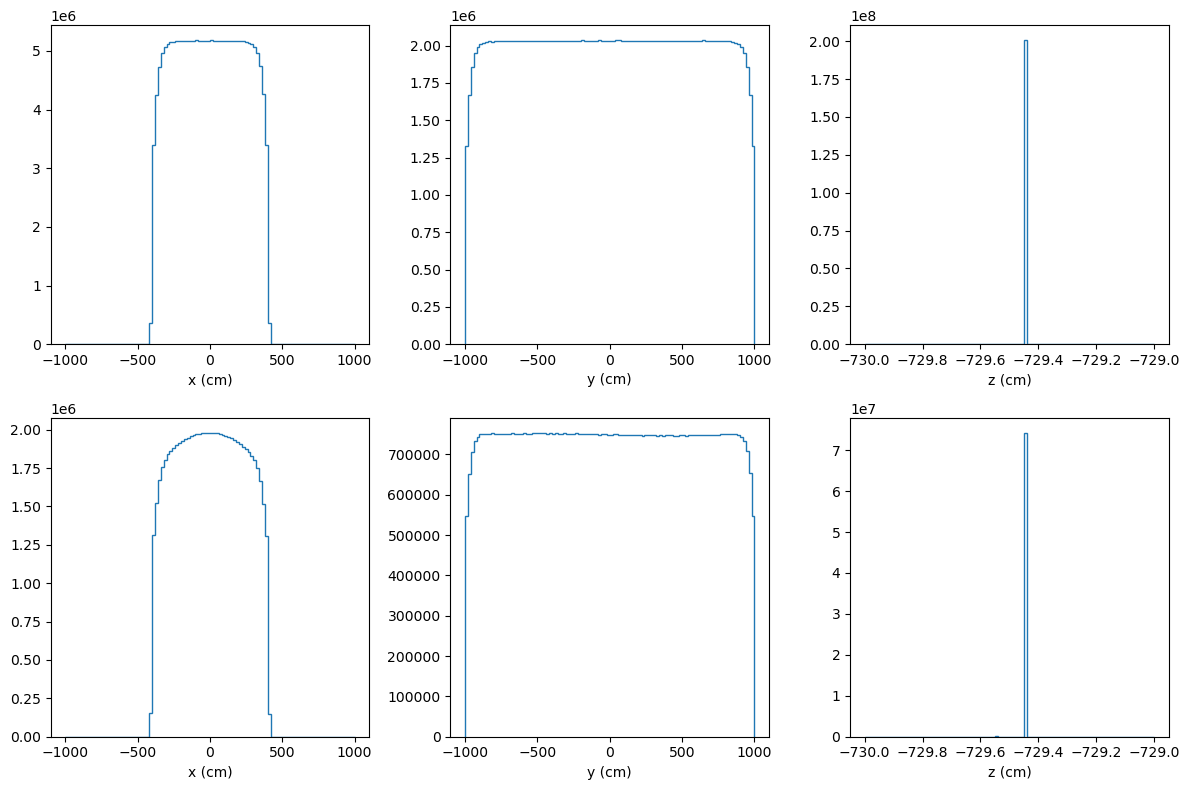

In [7]:
fig, axs = plt.subplots(2, 3, figsize = (12, 8), tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
n_bins = 100
xrange = (-1000,1000)
axs[0][0].hist(openskyfull[:,0], bins=n_bins, range=xrange, histtype='step');
axs[0][0].set_xlabel("x (cm)")
axs[0][1].hist(openskyfull[:,1], bins=n_bins, range=xrange, histtype='step');
axs[0][1].set_xlabel("y (cm)")
axs[0][2].hist(openskyfull[:,2], bins=n_bins, range=(-730,-729), histtype='step');
axs[0][2].set_xlabel("z (cm)")
axs[1][0].hist(tunnelfull[:,0], bins=n_bins, range=xrange, histtype='step');
axs[1][0].set_xlabel("x (cm)")
axs[1][1].hist(tunnelfull[:,1], bins=n_bins, range=xrange, histtype='step');
axs[1][1].set_xlabel("y (cm)")
axs[1][2].hist(tunnelfull[:,2], bins=n_bins, range=(-730,-729), histtype='step');
axs[1][2].set_xlabel("z (cm)")

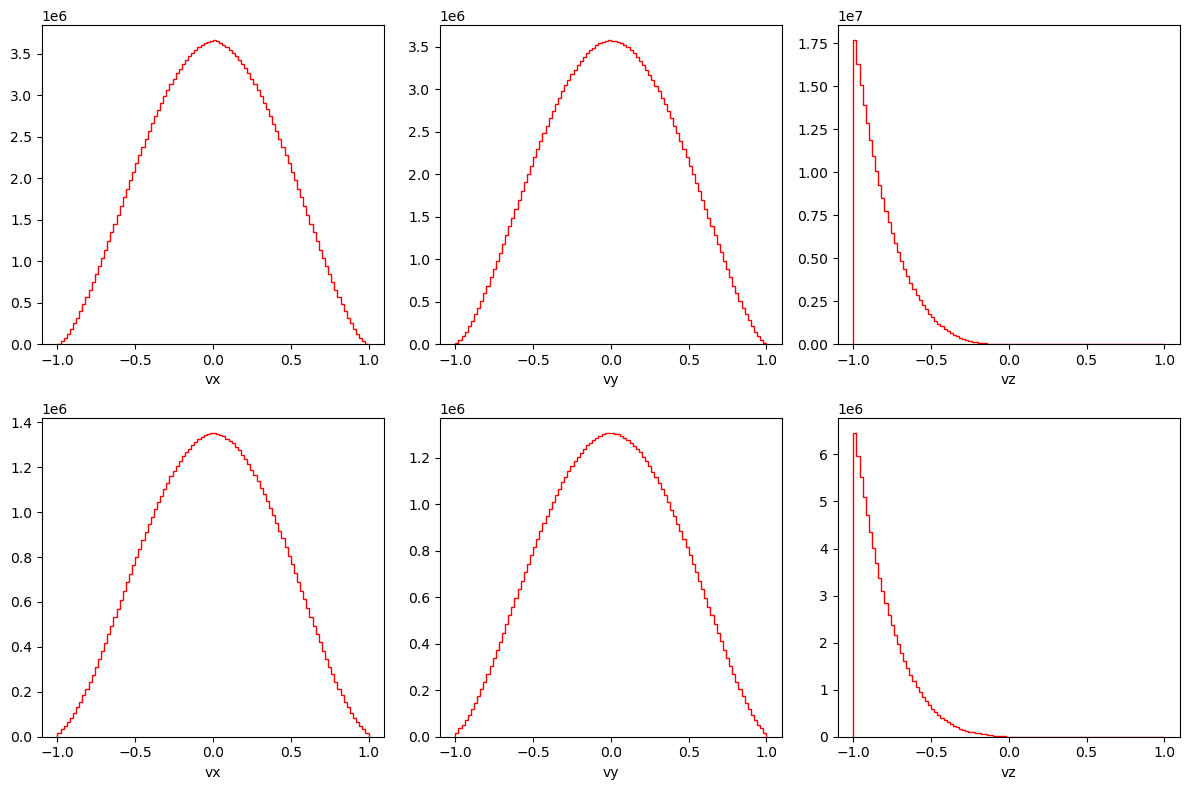

In [8]:
fig, axs = plt.subplots(2, 3, figsize = (12, 8), tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
n_bins = 100
color = 'r'
axs[0][0].hist(openskyfull[:,3], bins=n_bins, range=(-1,1), histtype='step', color=color);
axs[0][0].set_xlabel("vx");
axs[0][1].hist(openskyfull[:,4], bins=n_bins, range=(-1,1), histtype='step', color=color);
axs[0][1].set_xlabel("vy");
axs[0][2].hist(openskyfull[:,5], bins=n_bins, range=(-1,1), histtype='step', color=color);
axs[0][2].set_xlabel("vz");
axs[1][0].hist(tunnelfull[:,3], bins=n_bins, range=(-1,1), histtype='step', color=color);
axs[1][0].set_xlabel("vx");
axs[1][1].hist(tunnelfull[:,4], bins=n_bins, range=(-1,1), histtype='step', color=color);
axs[1][1].set_xlabel("vy");
axs[1][2].hist(tunnelfull[:,5], bins=n_bins, range=(-1,1), histtype='step', color=color);
axs[1][2].set_xlabel("vz");

We select two detector positions:
- 1m^2 detector placed at (0,0)
- 1m^2 detector placed at (-74,-75)

In [47]:
# Create a function that starts from the detector positions and returns the ratio histogram

def forwardPass(openskyData, tunnelData, detPositions, 
                detSize=100., detSizeZ=40., Z=1000.,
                bins=50, rangex=[-1500.,1500.], rangey=[-1500,1500]):
    # Compute limits of detector
    limits = []
    for i,pos in enumerate(detPositions):
        lim_temp = []
        lim_temp.append((pos[0]-detSize/2.,pos[0]+detSize/2.))
        lim_temp.append((pos[1]-detSize/2.,pos[1]+detSize/2.))
        limits.append(lim_temp)

    openskyMeas, tunnelMeas = [], []
    for i,lim in enumerate(limits):
        dsel_temp = DatasetSelector(limits=(lim[0],lim[1]), detsize=detSizeZ)
        openskyMeas.append(dsel_temp.get(openskyData))
        tunnelMeas.append(dsel_temp.get(tunnelData))

    # Get 2D histograms
    histograms, xedges, yedges = [], [], []
    totalXsky, totalYsky = [], []
    totalXtunnel, totalYtunnel = [], []
    for i in range(len(openskyMeas)):
        openskyData_temp = openskyMeas[i]
        tunnelData_temp = tunnelMeas[i]

        lsky = (Z-openskyData_temp[:,2])/openskyData_temp[:,5]
        xsky = openskyData_temp[:,0] + lsky * openskyData_temp[:,3]
        ysky = openskyData_temp[:,1] + lsky * openskyData_temp[:,4]
        ltunnel = (Z-tunnelData_temp[:,2])/tunnelData_temp[:,5]
        xtunnel = tunnelData_temp[:,0] + ltunnel * tunnelData_temp[:,3]
        ytunnel = tunnelData_temp[:,1] + ltunnel * tunnelData_temp[:,4]

        totalXsky += list(xsky)
        totalYsky += list(ysky)
        totalXtunnel += list(xtunnel)
        totalYtunnel += list(ytunnel)

        h1, x, y = np.histogram2d(xtunnel, ytunnel, bins=bins, range=[rangex,rangey])
        h2, x, y = np.histogram2d(xsky, ysky, bins=bins, range=[rangex,rangey])
        h = np.divide(h1, h2, where=(h2!= 0))
        histograms.append(h)
        xedges.append(x)
        yedges.append(y)

    totalXsky = np.array(totalXsky)
    totalYsky = np.array(totalYsky)
    totalXtunnel = np.array(totalXtunnel)
    totalYtunnel = np.array(totalYtunnel)

    h1, x, y = np.histogram2d(totalXtunnel, totalYtunnel, bins=bins, range=[rangex,rangey])
    h2, x, y = np.histogram2d(totalXsky, totalYsky, bins=bins, range=[rangex,rangey])
    h = np.divide(h1, h2, where=(h2!= 0))
    histograms.append(h)
    xedges.append(x)
    yedges.append(y)

    return histograms, xedges, yedges
        
        

xmin: -100.0 xmax: 0.0 ymin: -100.0 ymax: 0.0
(1309935, 6)
xmin: -100.0 xmax: 0.0 ymin: -100.0 ymax: 0.0
(498232, 6)
xmin: -100.0 xmax: 0.0 ymin: 0.0 ymax: 100.0
(1312059, 6)
xmin: -100.0 xmax: 0.0 ymin: 0.0 ymax: 100.0
(497793, 6)
xmin: 0.0 xmax: 100.0 ymin: 0.0 ymax: 100.0
(1311897, 6)
xmin: 0.0 xmax: 100.0 ymin: 0.0 ymax: 100.0
(496456, 6)


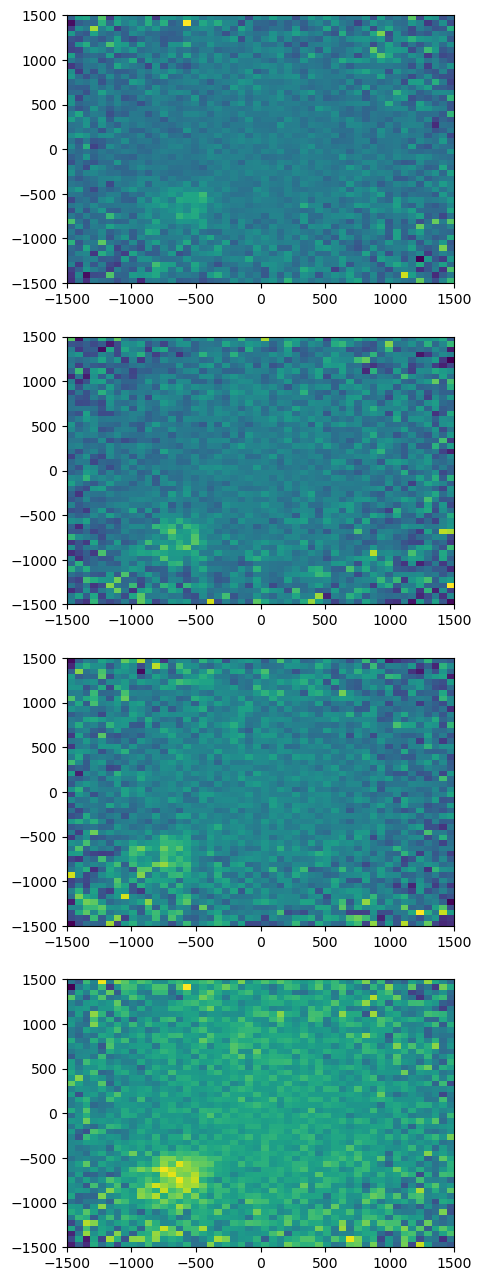

In [48]:
histograms, xedges, yedges = forwardPass(openskyfull, tunnelfull, [(-50,-50), (-50,50), (50,50)])

fig,ax = plt.subplots(len(histograms), 1, figsize = (5, 4*len(histograms)))

for i in range(len(histograms)):
    pc = ax[i].pcolorfast(xedges[i], yedges[i], histograms[i].T)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.46363636 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.44705882 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


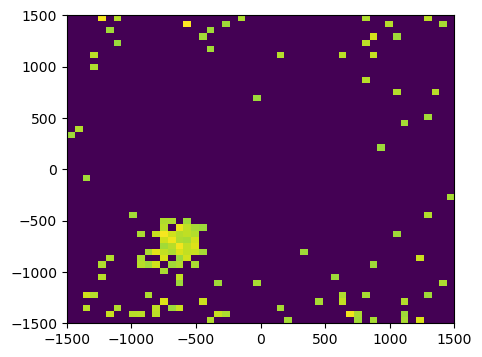

In [55]:
print(histograms[0]>0.9*np.max(histograms[0]))
htemp = histograms[3]*(histograms[3]>0.85*np.max(histograms[3]))
print(htemp)

fig,ax = plt.subplots(1, 1, figsize = (5, 4))
pc = ax.pcolorfast(xedges[0], yedges[0], htemp.T)

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F

tensor([[[[0.2292, 0.2727, 0.2358,  ..., 0.2992, 0.2021, 0.3226],
          [0.2967, 0.3824, 0.3333,  ..., 0.3821, 0.3306, 0.2895],
          [0.2432, 0.2252, 0.4636,  ..., 0.3387, 0.3710, 0.4138],
          ...,
          [0.3058, 0.3246, 0.3193,  ..., 0.3285, 0.2560, 0.3878],
          [0.3061, 0.2477, 0.3824,  ..., 0.3628, 0.4471, 0.3529],
          [0.2889, 0.3261, 0.4255,  ..., 0.3125, 0.3875, 0.3093]]]],
       dtype=torch.float64)
[[0.10768311 0.13396433 0.15718287 ... 0.1602713  0.13819715 0.11244088]
 [0.1340037  0.16639913 0.19485052 ... 0.19849867 0.17146373 0.13976621]
 [0.15725804 0.19487604 0.22771816 ... 0.23188346 0.20064303 0.16384691]
 ...
 [0.16082367 0.1974485  0.22842743 ... 0.22492315 0.19495894 0.1595369 ]
 [0.13802519 0.16959903 0.19631349 ... 0.1940643  0.16832988 0.13783543]
 [0.1117706  0.13748934 0.15927049 ... 0.15802742 0.13715935 0.11237439]]


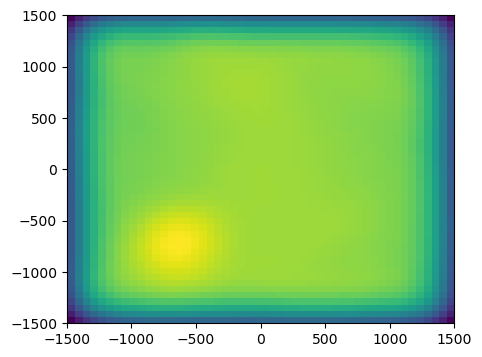

In [70]:
ratio_map = np.array(histograms[3], dtype=float)
ratio_map = torch.from_numpy(ratio_map)

# Create a 2D Gaussian smoothing kernel
kernel_size = 15
sigma = 3.
ax = torch.arange(-kernel_size // 2 + 1.0, kernel_size // 2 + 1.0)
xx, yy = torch.meshgrid(ax, ax, indexing="ij")
kernel = torch.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
kernel = kernel / kernel.sum()
kernel = kernel.view(1, 1, kernel_size, kernel_size)

if ratio_map.ndim == 2:
    ratio_map = ratio_map.unsqueeze(0).unsqueeze(0)
print(ratio_map)

smoothed = F.conv2d(ratio_map.double(), kernel.double(), padding="same")
print(np.array(smoothed[0][0]))

fig,ax = plt.subplots(1, 1, figsize = (5, 4))
pc = ax.pcolorfast(xedges[0], yedges[0], np.array(smoothed[0][0]).T)

In [71]:
class DifferentiableHistogram2D(nn.Module):

    def __init__(
        self,
        bins: tuple[int, int] = (60, 60),
        x_range: tuple[float, float] = (-1500.0, 1500.0),
        y_range: tuple[float, float] = (-1500.0, 1500.0),
    ):
        super().__init__()
        self.H_bins, self.W_bins = bins
        self.x_min, self.x_max = x_range
        self.y_min, self.y_max = y_range

    def forward(
        self,
        x_coords: torch.Tensor,
        y_coords: torch.Tensor,
        weights: torch.Tensor = None,
    ) -> torch.Tensor:
        """Args:

        x_coords: 1D Tensor of shape (N,)
        y_coords: 1D Tensor of shape (N,)
        weights: Optional 1D Tensor of shape (N,)
        Returns:
            2D continuous histogram of shape (H_bins, W_bins)
        """
        if weights is None:
            weights = torch.ones_like(x_coords)

        # 1. Normalize coordinates to continuous grid index coordinates [0, bins-1]
        x_norm = (x_coords - self.x_min) / (self.x_max - self.x_min) * (
            self.W_bins - 1
        )
        y_norm = (y_coords - self.y_min) / (self.y_max - self.y_min) * (
            self.H_bins - 1
        )

        # 2. Get bounding 4 neighbor cell indices
        x0 = torch.floor(x_norm).long()
        y0 = torch.floor(y_norm).long()
        x1 = x0 + 1
        y1 = y0 + 1

        # Clip indices to grid boundaries to avoid indexing errors
        x0_c = torch.clamp(x0, 0, self.W_bins - 1)
        x1_c = torch.clamp(x1, 0, self.W_bins - 1)
        y0_c = torch.clamp(y0, 0, self.H_bins - 1)
        y1_c = torch.clamp(y1, 0, self.H_bins - 1)

        # 3. Bilinear interpolation weights (differentiable w.r.t coordinates)
        w_x1 = x_norm - x0.float()
        w_x0 = 1.0 - w_x1
        w_y1 = y_norm - y0.float()
        w_y0 = 1.0 - w_y1

        w00 = weights * w_x0 * w_y0
        w01 = weights * w_x0 * w_y1
        w10 = weights * w_x1 * w_y0
        w11 = weights * w_x1 * w_y1

        # 4. Scatter add into 2D grid
        hist = torch.zeros(
            (self.H_bins, self.W_bins),
            dtype=x_coords.dtype,
            device=x_coords.device,
        )

        hist.index_put_((y0_c, x0_c), w00, accumulate=True)
        hist.index_put_((y1_c, x0_c), w01, accumulate=True)
        hist.index_put_((y0_c, x1_c), w10, accumulate=True)
        hist.index_put_((y1_c, x1_c), w11, accumulate=True)

        return hist

In [74]:
class ChamberBlindDetectorLoss(nn.Module):

    def __init__(
        self, kernel_size: int = 15, sigma: float = 3.0, temperature: float = 0.1
    ):
        super().__init__()
        self.temperature = temperature

        # Create a 2D Gaussian smoothing kernel
        ax = torch.arange(-kernel_size // 2 + 1.0, kernel_size // 2 + 1.0)
        xx, yy = torch.meshgrid(ax, ax, indexing="ij")
        kernel = torch.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
        kernel = kernel / kernel.sum()

        # Shape (out_channels, in_channels, H, W) for conv2d
        self.register_buffer(
            "kernel", kernel.view(1, 1, kernel_size, kernel_size)
        )

    def forward(self, ratio_map: torch.Tensor, valid_mask: torch.Tensor = None):
        """Args:

        ratio_map: Tensor of shape (1, 1, H, W) or (H, W)
        valid_mask: Optional boolean mask (1 for valid sky bins, 0 for edge
        voids)
        """
        if ratio_map.ndim == 2:
            ratio_map = ratio_map.unsqueeze(0).unsqueeze(0)

        # 1. Spatially smooth to aggregate chamber signal and suppress single-pixel noise
        smoothed = F.conv2d(ratio_map, self.kernel, padding="same")

        if valid_mask is not None:
            if valid_mask.ndim == 2:
                valid_mask = valid_mask.unsqueeze(0).unsqueeze(0)
            smoothed = smoothed * valid_mask
            flat_smoothed = smoothed[valid_mask > 0]
        else:
            flat_smoothed = smoothed.flatten()

        # 2. Background statistics
        mu_bg = torch.mean(flat_smoothed)
        sigma_bg = torch.std(flat_smoothed) + 1e-6

        # 3. SoftMax-based peak approximation (smooth, differentiable max)
        # LogSumExp gives a smooth approximation of max(smoothed)
        peak_val = (
            self.temperature
            * torch.logsumexp(flat_smoothed / self.temperature, dim=0)
            - self.temperature * torch.log(torch.tensor(flat_smoothed.numel()))
        )

        # 4. Significance Z-score
        z_score = (peak_val - mu_bg) / sigma_bg

        # Return negative Z-score for minimization
        return -z_score

In [79]:
def project_muons(data, detPos, mode='sky', detSize=100., detSizeZ=40.):
    # Compute limits of detector
    limits = []
    limits.append((detPos[0]-detSize/2.,detPos[0]+detSize/2.))
    limits.append((detPos[1]-detSize/2.,detPos[1]+detSize/2.))

    dsel_temp = DatasetSelector(limits=(limits[0],limits[1]), detsize=detSizeZ)
    dataSel = dsel_temp.get(data)

    l = (Z-dataSel[:,2])/dataSel[:,5]
    x = dataSel[:,0] + l * dataSel[:,3]
    y = dataSel[:,1] + l * dataSel[:,4]

    return x, y

In [81]:
# 1. Define detector parameters as optimizable tensors
detector_pos = torch.nn.Parameter(torch.tensor([0.0, -50.0], requires_grad=True))
optimizer = torch.optim.Adam([detector_pos], lr=1.0)

hist_builder = DifferentiableHistogram2D(bins=(50, 50))
blind_loss = ChamberBlindDetectorLoss()

# 2. Forward pass
x_tunnel, y_tunnel = project_muons(tunnelfull, (-50,-50), mode='tunnel')
x_sky, y_sky       = project_muons(openskyfull, (-50,-50), mode='sky')

xmin: -100.0 xmax: 0.0 ymin: -100.0 ymax: 0.0
(498232, 6)
xmin: -100.0 xmax: 0.0 ymin: -100.0 ymax: 0.0
(1309935, 6)


In [82]:
H_tunnel = hist_builder(torch.from_numpy(x_tunnel), torch.from_numpy(y_tunnel))
H_sky    = hist_builder(torch.from_numpy(x_sky), torch.from_numpy(y_sky))

# 3. Differentiable ratio map with epsilon stabilizer
ratio_map = H_tunnel / (H_sky + 1e-4)
print(ratio_map)

# 4. Compute loss & backpropagate
#loss = blind_loss(ratio_map)
#loss.backward()
#optimizer.step()

tensor([[0.3656, 0.4037, 0.3842,  ..., 0.3771, 0.3638, 0.3685],
        [0.3642, 0.5333, 0.4927,  ..., 0.2736, 0.4120, 0.3734],
        [0.3758, 0.4367, 0.4591,  ..., 0.4118, 0.4687, 0.3708],
        ...,
        [0.3621, 0.4064, 0.4295,  ..., 0.3163, 0.3573, 0.3798],
        [0.3545, 0.3464, 0.3185,  ..., 0.4672, 0.3734, 0.3666],
        [0.3541, 0.3627, 0.3865,  ..., 0.3965, 0.3820, 0.3746]])


In [9]:
detsize = 40.
dsel1 = DatasetSelector(limits=((-100,0),(-100,0)), detsize=detsize)  
dsel2 = DatasetSelector(limits=((-100,0),(0,100)), detsize=detsize)
dsel3 = DatasetSelector(limits=((0,100),(-100,0)), detsize=detsize)
dsel4 = DatasetSelector(limits=((0,100),(0,100)), detsize=detsize)

opensky = []
tunnel = []

opensky1 = dsel1.get(openskyfull)
tunnel1 = dsel1.get(tunnelfull)
opensky2 = dsel2.get(openskyfull)
tunnel2 = dsel2.get(tunnelfull)
opensky3 = dsel3.get(openskyfull)
tunnel3 = dsel3.get(tunnelfull)
opensky4 = dsel4.get(openskyfull)
tunnel4 = dsel4.get(tunnelfull)

opensky.append(opensky1)
opensky.append(opensky2)
opensky.append(opensky3)
opensky.append(opensky4)
tunnel.append(tunnel1)
tunnel.append(tunnel2)
tunnel.append(tunnel3)
tunnel.append(tunnel4)

xmin: -100 xmax: 0 ymin: -100 ymax: 0
(1309935, 6)
xmin: -100 xmax: 0 ymin: -100 ymax: 0
(498232, 6)
xmin: -100 xmax: 0 ymin: 0 ymax: 100
(1312059, 6)
xmin: -100 xmax: 0 ymin: 0 ymax: 100
(497793, 6)
xmin: 0 xmax: 100 ymin: -100 ymax: 0
(1309331, 6)
xmin: 0 xmax: 100 ymin: -100 ymax: 0
(496901, 6)
xmin: 0 xmax: 100 ymin: 0 ymax: 100
(1311897, 6)
xmin: 0 xmax: 100 ymin: 0 ymax: 100
(496456, 6)


In [15]:
%jsroot on
def drawProjectionROOT(data_open, data_tunnel, Z, out='out/', name='test'):
    if not os.path.exists(out): os.makedirs(out)

    lsky = (Z-data_open[:,2])/data_open[:,5]
    xsky = data_open[:,0] + lsky * data_open[:,3]
    ysky = data_open[:,1] + lsky * data_open[:,4]
    ltunnel = (Z-data_tunnel[:,2])/data_tunnel[:,5]
    xtunnel = data_tunnel[:,0] + ltunnel * data_tunnel[:,3]
    ytunnel = data_tunnel[:,1] + ltunnel * data_tunnel[:,4]

    c = R.TCanvas("c","",800,800)
    c.cd()
    h_o = R.TH2D("h_o",";x (cm);y (cm)",50,-2000.,2000.,50,-2000.,2000)
    h_t = R.TH2D("h_t",";x (cm);y (cm)",50,-2000.,2000.,50,-2000.,2000)
    h_o.FillN(len(xsky), np.array(xsky, dtype=float), np.array(ysky, dtype=float), np.ones(len(xsky)))
    h_t.FillN(len(xtunnel), np.array(xtunnel,dtype=float), np.array(ytunnel,dtype=float), np.ones(len(xtunnel)))
    h_ratio = h_t.Clone()
    h_ratio.SetMinimum(0.)
    h_ratio.SetMaximum(1.)
    h_ratio.SetDirectory(0)
    h_ratio.Divide(h_o)
    h_ratio.Draw("COLZ")
    c.SaveAs(f"{out}/{name}_{Z}.png")
    return c

In [24]:
c = drawProjectionROOT(opensky1, tunnel1, Z=1000., out='out_test', name='p0_p100');

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file out_test/p0_p100_1000.0.png has been created


In [16]:
R.gStyle.SetOptStat(0)
for Z in np.linspace(500,2500,51):
    print(f"Generating hist for z = {Z} cm")
    c = drawProjectionROOT(opensky2, tunnel2, Z);

Generating hist for z = 500.0 cm
Generating hist for z = 540.0 cm
Generating hist for z = 580.0 cm
Generating hist for z = 620.0 cm
Generating hist for z = 660.0 cm
Generating hist for z = 700.0 cm
Generating hist for z = 740.0 cm
Generating hist for z = 780.0 cm
Generating hist for z = 820.0 cm
Generating hist for z = 860.0 cm
Generating hist for z = 900.0 cm
Generating hist for z = 940.0 cm
Generating hist for z = 980.0 cm
Generating hist for z = 1020.0 cm
Generating hist for z = 1060.0 cm
Generating hist for z = 1100.0 cm
Generating hist for z = 1140.0 cm
Generating hist for z = 1180.0 cm
Generating hist for z = 1220.0 cm
Generating hist for z = 1260.0 cm
Generating hist for z = 1300.0 cm
Generating hist for z = 1340.0 cm
Generating hist for z = 1380.0 cm
Generating hist for z = 1420.0 cm
Generating hist for z = 1460.0 cm
Generating hist for z = 1500.0 cm
Generating hist for z = 1540.0 cm
Generating hist for z = 1580.0 cm
Generating hist for z = 1620.0 cm
Generating hist for z = 166

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file out//test_500.0.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file out//test_540.0.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file out//test_580.0.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file out//test_620.0.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file out//test_660.0.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file out//test_700.0.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file out//test_740.0.png has been created
Warning in <T

In [17]:
import glob
from PIL import Image

def make_gif(frame_folder):
    frames = [Image.open(image) for image in sorted(glob.glob(f"{frame_folder}/*.png"))]
    frame_one = frames[0]
    frame_one.save("position2.gif", format="GIF", append_images=frames,
               save_all=True, duration=100, loop=0)

make_gif("out/")

In [36]:
def drawProjection(dataSky, dataTunnel, Z):
        
    fig,ax = plt.subplots(len(dataSky)+1, 3, figsize = (16, 4*(len(dataSky)+1)))

    totalXsky, totalYsky = [], []
    totalXtunnel, totalYtunnel = [], []
    for i in range(len(dataSky)):
        lsky = (Z-dataSky[i][:,2])/dataSky[i][:,5]
        xsky = dataSky[i][:,0] + lsky * dataSky[i][:,3]
        ysky = dataSky[i][:,1] + lsky * dataSky[i][:,4]

        totalXsky += list(xsky)
        totalYsky += list(ysky)
        
        ltunnel = (Z-dataTunnel[i][:,2])/dataTunnel[i][:,5]
        xtunnel = dataTunnel[i][:,0] + ltunnel * dataTunnel[i][:,3]
        ytunnel = dataTunnel[i][:,1] + ltunnel * dataTunnel[i][:,4]

        totalXtunnel += list(xtunnel)
        totalYtunnel += list(ytunnel)
        
        colors.LogNorm()
        rangex = [-1500,1500]
        rangey = [-1500,1500]
        bins = [50,50]
        ax[i][0].hist2d(xsky, ysky, bins=bins, range=[rangex,rangey])
        ax[i][1].hist2d(xtunnel, ytunnel, bins=bins, range=[rangex,rangey])
        h1, xedges, yedges = np.histogram2d(xtunnel, ytunnel, bins=bins, range=[rangex,rangey])
        h2, xedges, yedges = np.histogram2d(xsky, ysky, bins=bins, range=[rangex,rangey])
        h = np.divide(h1, h2, where=(h2!= 0))
        pc = ax[i][2].pcolorfast(xedges, yedges, h.T)

    bins=50
    totalXsky = np.array(totalXsky)
    totalYsky = np.array(totalYsky)
    totalXtunnel = np.array(totalXtunnel)
    totalYtunnel = np.array(totalYtunnel)
    ax[i+1][0].hist2d(totalXsky, totalYsky, bins=bins, range=[rangex,rangey])
    ax[i+1][1].hist2d(totalXtunnel, totalYtunnel, bins=bins, range=[rangex,rangey])
    h1, xedges, yedges = np.histogram2d(totalXtunnel, totalYtunnel, bins=bins, range=[rangex,rangey])
    h2, xedges, yedges = np.histogram2d(totalXsky, totalYsky, bins=bins, range=[rangex,rangey])
    h = np.divide(h1, h2, where=(h2!= 0))
    pc = ax[i+1][2].pcolorfast(xedges, yedges, h.T)

In [12]:
def drawProjection(dataSky, dataTunnel, Z):
        
    fig,ax = plt.subplots(len(dataSky), 3, figsize = (16, 16))

    for i in range(len(dataSky)):
        lsky = (Z-dataSky[i][:,2])/dataSky[i][:,5]
        xsky = dataSky[i][:,0] + lsky * dataSky[i][:,3]
        ysky = dataSky[i][:,1] + lsky * dataSky[i][:,4]
    
        ltunnel = (Z-dataTunnel[i][:,2])/dataTunnel[i][:,5]
        xtunnel = dataTunnel[i][:,0] + ltunnel * dataTunnel[i][:,3]
        ytunnel = dataTunnel[i][:,1] + ltunnel * dataTunnel[i][:,4]

        ax[i][0].hist2d(xsky, ysky, bins=[50,50], range=[[-2000, 2000],[-2000, 2000]])
        ax[i][1].hist2d(xtunnel, ytunnel, bins=[50,50], range=[[-2000, 2000],[-2000, 2000]])
        h1, xedges, yedges = np.histogram2d(xtunnel, ytunnel, bins=[50,50], range=[[-2000, 2000],[-2000, 2000]])
        h2, xedges, yedges = np.histogram2d(xsky, ysky, bins=[50,50], range=[[-2000, 2000],[-2000, 2000]])
        h = np.divide(h1, h2, where=(h2!= 0))
        pc = ax[i][2].pcolorfast(xedges, yedges, h.T)

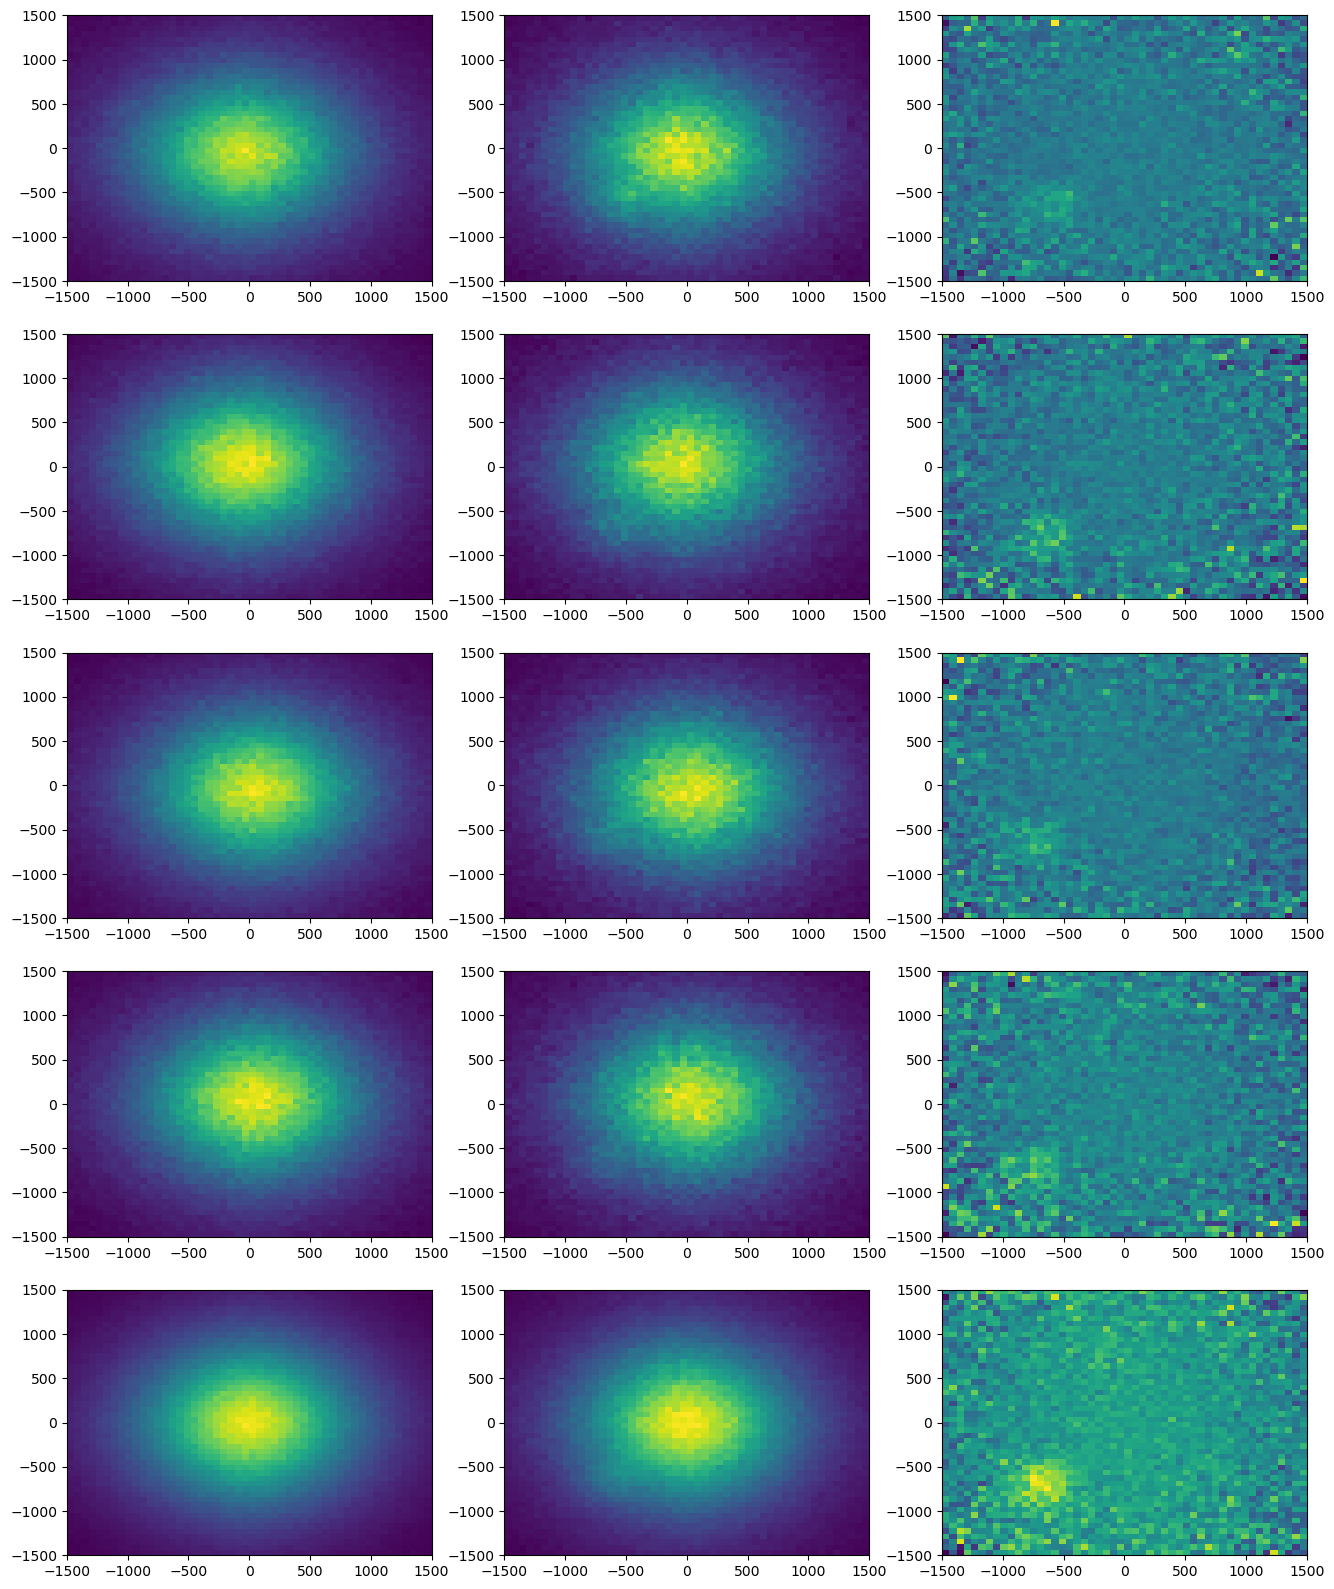

In [38]:
drawProjection(opensky, tunnel, 1000)
plt.savefig('fig.png')

In [20]:
# Make partition of detector

def getPartitionMap(dataDetector, detCoords=((-100,0),(-100,0)), nDiv=10):
    partitionMap = {}
    for i in range(nDiv):
        for j in range(nDiv):
            partitionMap[f"{i}_{j}"] = {}
            xrange = detCoords[0][1] - detCoords[0][0]
            xlim = (detCoords[0][0] + xrange/nDiv * i, detCoords[0][0] + xrange/nDiv * (i+1))
            yrange = detCoords[1][1] - detCoords[1][0]
            ylim = (detCoords[1][0] + yrange/nDiv * j, detCoords[1][0] + yrange/nDiv * (j+1))
            partitionMap[f"{i}_{j}"]["limits"] = (xlim,ylim)
            partitionMap[f"{i}_{j}"]["data"] = dataDetector[(dataDetector[:, 0] > xlim[0]) & (dataDetector[:, 0] < xlim[1])
                & (dataDetector[:,1] > ylim[0]) & (dataDetector[:,1] < ylim[1])]
    return partitionMap

In [29]:
partOpen1 = getPartitionMap(opensky1, detCoords=((-100,0),(-100,0)), nDiv=10)
partTunnel1 = getPartitionMap(tunnel1, detCoords=((-100,0),(-100,0)), nDiv=10)
print(partOpen1["0_0"]["data"])

[[-9.0454567e+01 -9.3898399e+01 -7.2945001e+02  5.4668713e-01
   4.2889062e-01 -7.1915644e-01]
 [-9.7992531e+01 -9.5383179e+01 -7.2945001e+02  4.4120387e-03
   1.6642836e-01 -9.8604369e-01]
 [-9.4815567e+01 -9.1869446e+01 -7.2945001e+02  9.6000076e-05
   3.3507761e-01 -9.4219053e-01]
 ...
 [-9.1110474e+01 -9.7575142e+01 -7.2945001e+02 -1.6567160e-01
   4.0367794e-01 -8.9977610e-01]
 [-9.7867851e+01 -9.1141403e+01 -7.2945001e+02  2.2008030e-01
   4.6775097e-01 -8.5602200e-01]
 [-9.3090485e+01 -9.2849770e+01 -7.2945001e+02  5.0598550e-01
  -1.5109755e-01 -8.4920448e-01]]


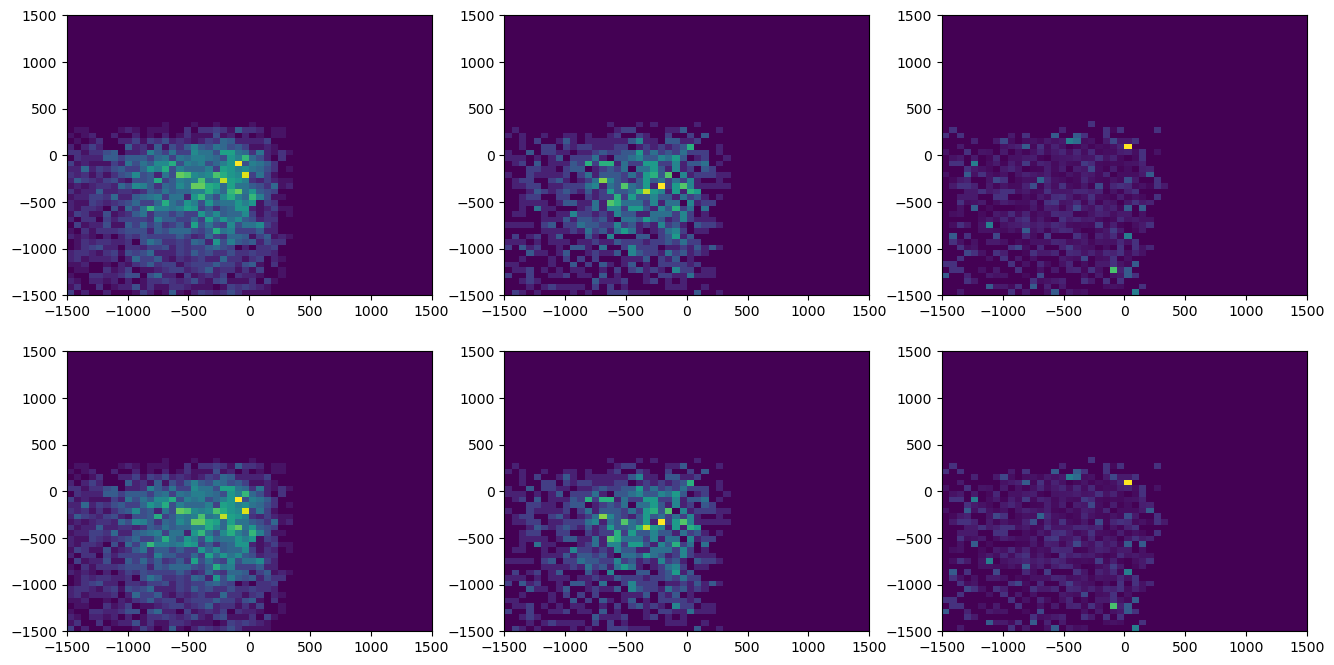

In [37]:
drawProjection([partOpen1["0_0"]["data"]], [partTunnel1["0_0"]["data"]], 1000)